In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_rfe_without_bor.csv')
clinical_gex

,Unnamed: 0,m_stage_prep__M_stage,remainder__age,remainder__CYBB,remainder__TSPAN7,remainder__CPN1,remainder__LGALS3,remainder__RNF182,remainder__CTSK,remainder__AKR1C3,...,remainder__SNORA7A,remainder__GBP5,remainder__PLAT,remainder__TSPAN10,remainder__ITGB3,remainder__P2RX7,remainder__VCAN,remainder__FCER1G,remainder__S100B,pfs_label
0,0,1.0,26.0,6.365546,7.004752,6.708272,9.645812,4.833599,8.773568,5.174651,...,4.806668,5.733141,7.719349,7.142719,8.326558,6.156618,6.787891,10.968532,8.616702,0
1,1,0.0,58.0,5.799843,9.572148,8.243610,10.134595,4.825007,10.121792,5.160210,...,3.948992,5.113811,7.820467,7.400251,4.629680,6.761518,6.048721,7.434155,7.824407,2
2,2,0.0,45.0,7.741959,7.440319,5.843611,9.479156,5.061139,7.912981,5.387827,...,4.576240,7.196424,6.980341,7.052908,5.755193,6.260890,7.066907,9.908728,7.443815,2
3,3,2.0,48.0,7.748962,6.174459,5.797310,9.164719,4.836158,10.267321,5.619920,...,5.566031,6.075199,7.081143,7.135489,4.524849,6.352753,9.909150,9.664854,4.875958,0
4,4,2.0,33.0,6.653502,7.220767,6.083425,8.733935,4.819080,9.146331,5.233270,...,6.634484,4.881193,7.537365,7.201527,4.883450,7.251177,7.040934,8.223507,7.778088,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,120,2.0,62.0,6.524451,6.377548,5.387022,8.732457,4.730565,8.293261,5.700180,...,5.186016,6.177634,7.009404,6.140929,5.297617,6.269066,7.306095,9.422969,6.546015,2
121,121,2.0,49.0,6.214630,6.733632,5.619678,9.855872,6.049764,10.158871,5.028180,...,5.186016,5.111762,8.622177,6.716541,6.120237,7.987287,7.061020,6.469659,6.326626,0
122,122,2.0,68.0,8.103136,6.684949,5.350635,9.875511,4.718063,9.139950,5.073155,...,5.186016,7.296543,7.586239,6.920163,5.002121,7.462024,8.035135,9.036223,6.820134,0
123,123,2.0,72.0,7.079539,7.043135,6.544207,9.733837,5.445243,7.628470,5.204055,...,5.186016,6.086090,6.533277,8.827673,5.639136,6.901176,7.195321,8.029269,7.428094,0


In [8]:
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['pfs_label', 'Unnamed: 0'], axis=1)
x.head()

,m_stage_prep__M_stage,remainder__age,remainder__CYBB,remainder__TSPAN7,remainder__CPN1,remainder__LGALS3,remainder__RNF182,remainder__CTSK,remainder__AKR1C3,remainder__ERRFI1,...,remainder__EPDR1,remainder__SNORA7A,remainder__GBP5,remainder__PLAT,remainder__TSPAN10,remainder__ITGB3,remainder__P2RX7,remainder__VCAN,remainder__FCER1G,remainder__S100B
0,1.0,26.0,6.365546,7.004752,6.708272,9.645812,4.833599,8.773568,5.174651,7.030409,...,6.775539,4.806668,5.733141,7.719349,7.142719,8.326558,6.156618,6.787891,10.968532,8.616702
1,0.0,58.0,5.799843,9.572148,8.243610,10.134595,4.825007,10.121792,5.160210,5.820270,...,6.658401,3.948992,5.113811,7.820467,7.400251,4.629680,6.761518,6.048721,7.434155,7.824407
2,0.0,45.0,7.741959,7.440319,5.843611,9.479156,5.061139,7.912981,5.387827,7.054025,...,6.716163,4.576240,7.196424,6.980341,7.052908,5.755193,6.260890,7.066907,9.908728,7.443815
3,2.0,48.0,7.748962,6.174459,5.797310,9.164719,4.836158,10.267321,5.619920,6.203316,...,6.727260,5.566031,6.075199,7.081143,7.135489,4.524849,6.352753,9.909150,9.664854,4.875958
4,2.0,33.0,6.653502,7.220767,6.083425,8.733935,4.819080,9.146331,5.233270,6.035462,...,6.573656,6.634484,4.881193,7.537365,7.201527,4.883450,7.251177,7.040934,8.223507,7.778088


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif, RFECV
from xgboost import XGBClassifier

clf = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=clf, cv=cv_split, scoring='f1_macro', n_jobs=-1, step=1)

xgboost_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,      # keep small — 125 samples
    max_depth=3,           # shallow trees — prevents overfit
    learning_rate=0.05,
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    reg_alpha=1.0,         # L1 regulariazation
    reg_lambda=1.0,        # L2 regularization
    eval_metric='mlogloss',
    random_state=42
)

# feat_select_pipe = Pipeline([
#     ('variance', VarianceThreshold(threshold=0.90)),
#     # ('selectk', SelectKBest(mutual_info_classif, k=20)),
#     ('rfecv', rfecv),
#     ('classifier', xgboost_clf)
# ])

results = cross_validate(
    xgboost_clf, x, y,
    cv=cv_split,
    scoring=['roc_auc_ovo', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

print(f"ROC-AUC (OVO)   : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Macro F1        : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")


ROC-AUC (OVO)   : 0.764 ± 0.040
Macro F1        : 0.532 ± 0.138


                     precision    recall  f1-score   support

  Short resp (n=66)       0.65      0.91      0.75        66
Intermediate (n=27)       0.75      0.44      0.56        27
   Long resp (n=32)       0.56      0.28      0.38        32

           accuracy                           0.65       125
          macro avg       0.65      0.54      0.56       125
       weighted avg       0.65      0.65      0.62       125



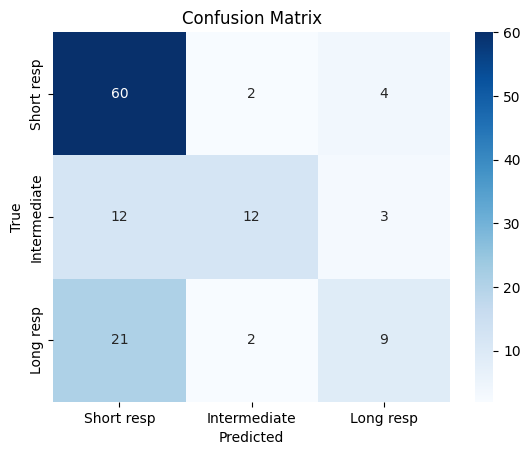

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = cross_val_predict(xgboost_clf, x, y, cv=cv_split, n_jobs=-1)
print(classification_report(y, y_pred, 
      target_names=['Short resp (n=66)', 
                    'Intermediate (n=27)', 
                    'Long resp (n=32)']))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Short resp','Intermediate','Long resp'],
            yticklabels=['Short resp','Intermediate','Long resp'],
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [11]:
# xgboost_clf = XGBClassifier(
#     objective='multi:softprob',
#     num_class=3,
#     n_estimators=100,      # keep small — 125 samples
#     max_depth=3,           # shallow trees — prevents overfit
#     learning_rate=0.05,
#     subsample=0.8,         # row sampling
#     colsample_bytree=0.8,  # feature sampling
#     reg_alpha=1.0,         # L1 regulariazation
#     reg_lambda=1.0,        # L2 regularization
#     eval_metric='mlogloss',
#     random_state=42
# )

In [12]:
# import xgboost as xgb

# x_rfe_df = pd.DataFrame(x_rfe, columns=rfecv.get_feature_names_out())
# xgboost_clf.fit(x_rfe_df, y)

# fig, ax = plt.subplots(figsize=(16, 12))
# xgb.plot_importance(xgboost_clf, ax=ax)
# plt.tight_layout()
# plt.show()